# Feature Engineering

In this section, we construct new predictive features from raw customer data.

The goal is to:
- Capture hidden behavioral patterns
- Improve model interpretability
- Increase predictive power
- Translate business logic into machine learning signals

We design 10 custom features based on:
- Customer tenure behavior
- Service usage patterns
- Billing and payment behavior
- Risk and loyalty indicators

Each feature is accompanied by a short business hypothesis explaining why it may help predict customer churn.

In [1]:
import pandas as pd

df = pd.read_csv("../data/train.csv")

# Data Cleaning (Based on EDA)

From EDA, we found no explicit missing values, but `TotalCharges` had hidden missing values stored as empty strings.

We converted it to numeric and handled the resulting NaN values before modeling.

In [2]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].isnull().sum()

np.int64(8)

In [3]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

## TenureRange
We convert continuous tenure into meaningful customer lifecycle groups.

In [4]:
bins = [0, 12, 24, 36, 48, 60, float("inf")]
labels = ["0-12", "12-24", "24-36", "36-48", "48-60", "60+"]

df["TenureRange"] = pd.cut(df["tenure"], bins=bins, labels=labels)
df["TenureRange"].value_counts().sort_index()

TenureRange
0-12     1729
12-24     818
24-36     669
36-48     621
48-60     658
60+      1131
Name: count, dtype: int64

Customer lifecycle grouping (new vs loyal customers).

## TotalServices
We count the number of active services per customer.

In [5]:
service_cols = [
"PhoneService","OnlineSecurity","OnlineBackup",
"DeviceProtection","TechSupport","StreamingTV","StreamingMovies"
]

df["TotalServices"] = (
    (df["PhoneService"] == "Yes").astype(int) +
    (df["OnlineSecurity"] == "Yes").astype(int) +
    (df["OnlineBackup"] == "Yes").astype(int) +
    (df["DeviceProtection"] == "Yes").astype(int) +
    (df["TechSupport"] == "Yes").astype(int) +
    (df["StreamingTV"] == "Yes").astype(int) +
    (df["StreamingMovies"] == "Yes").astype(int)
)

In [6]:
df["TotalServices"].describe()

count    5634.000000
mean        2.958821
std         1.849784
min         0.000000
25%         1.000000
50%         3.000000
75%         4.000000
max         7.000000
Name: TotalServices, dtype: float64

Captures overall service adoption strength.

## Security
Combination of OnlineSecurity and DeviceProtection.

In [7]:
df["Security"] = (
    (df["OnlineSecurity"] == "Yes") &
    (df["DeviceProtection"] == "Yes")
).astype(int)
df["Security"].value_counts()

Security
0    4753
1     881
Name: count, dtype: int64

Detects customers with strong security engagement.

## Entertainment
StreamingTV and StreamingMovies together.

In [8]:
df["Entertainment"] = (
    (df["StreamingTV"] == "Yes") &
    (df["StreamingMovies"] == "Yes")
).astype(int)
df["Entertainment"].value_counts()

Entertainment
0    4057
1    1577
Name: count, dtype: int64

Identifies heavy streaming users.

## SeniorTechSupport
Senior customers with tech support.

In [9]:
df["SeniorTechSupport"] = (
    (df["SeniorCitizen"] == 1) &
    (df["TechSupport"] == "Yes")
).astype(int)
df["SeniorTechSupport"].value_counts()

SeniorTechSupport
0    5424
1     210
Name: count, dtype: int64

Flags vulnerable users needing support.

## BillingAndPayment
High-risk payment behavior pattern.

In [10]:
df["BillingAndPayment"] = (
    (df["PaperlessBilling"] == "Yes") &
    (df["PaymentMethod"] == "Electronic check")
).astype(int)
df["BillingAndPayment"].value_counts()

BillingAndPayment
0    4244
1    1390
Name: count, dtype: int64

High-risk payment behavior indicator.

## MonthlyChargesRange
We discretize MonthlyCharges into fixed-width bins (20 units) to capture pricing segments.

In [11]:
bins = list(range(0, int(df["MonthlyCharges"].max()) + 20, 20))
labels = [f"{i}-{i+20}" for i in bins[:-1]]

df["MonthlyChargesRange"] = pd.cut(df["MonthlyCharges"], bins=bins, labels=labels, include_lowest=True)
df["MonthlyChargesRange"].value_counts()

MonthlyChargesRange
80-100     1423
60-80      1144
20-40       947
40-60       863
100-120     738
0-20        519
Name: count, dtype: int64

Groups customers by pricing tiers.

## AvgMonthlyPerService
We compute cost efficiency per active service.

In [12]:
df["AvgMonthlyPerService"] = df["MonthlyCharges"] / df["TotalServices"]

median_value = df["MonthlyCharges"].median()
df.loc[df["TotalServices"] == 0, "AvgMonthlyPerService"] = median_value

In [13]:
df["AvgMonthlyPerService"].describe()

count    5634.000000
mean       26.387755
std        14.361658
min        10.416667
25%        18.383333
50%        20.860000
75%        28.579167
max        77.900000
Name: AvgMonthlyPerService, dtype: float64

Measures cost efficiency per service usage.

## TenureContractRisk
We flag high-risk customers with short tenure and month-to-month contracts.

In [14]:
df["TenureContractRisk"] = (
    (df["Contract"] == "Month-to-month") &
    (df["tenure"] <= 12)
).astype(int)
df["TenureContractRisk"].value_counts()

TenureContractRisk
0    4040
1    1594
Name: count, dtype: int64

High churn risk segment detector.

## LoyaltyFactor
We build a 1–5 loyalty score based on tenure and contract stability.

In [15]:
def loyalty_score(row):
    if row["Contract"] == "Month-to-month":
        if row["tenure"] <= 12:
            return 1
        elif row["tenure"] <= 24:
            return 2
        else:
            return 3
    elif row["Contract"] == "One year":
        if row["tenure"] <= 24:
            return 3
        else:
            return 4
    else:
        return 5

df["LoyaltyFactor"] = df.apply(loyalty_score, axis=1)
df["LoyaltyFactor"].value_counts()

LoyaltyFactor
1    1594
5    1359
3    1182
4     919
2     580
Name: count, dtype: int64

Compact loyalty scoring from contract + tenure.

We successfully engineered 10 domain-driven features capturing:
- Customer lifecycle (TenureRange, LoyaltyFactor)
- Service engagement (TotalServices, Entertainment, Security)
- Financial behavior (BillingAndPayment, AvgMonthlyPerService)
- Risk signals (TenureContractRisk, SeniorTechSupport)
- Pricing segmentation (MonthlyChargesRange)

These features transform raw telecom data into structured behavioral signals for churn prediction.

# Data Preprocessing

In this stage, we prepare the dataset for machine learning models.

The main goal is to convert raw and structured data into a clean numerical format suitable for training.

We ensure:
- No data leakage between training and test sets
- Proper encoding of categorical variables
- Scaling of numerical features
- Consistent transformation pipeline for reproducibility

This step is critical because machine learning models can only learn from numerical inputs, and improper preprocessing can lead to misleading performance results.

## Remove identifier column
We drop customerID because it has no predictive value.

In [16]:
df = df.drop("customerID", axis=1)

In [17]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TenureRange,TotalServices,Security,Entertainment,SeniorTechSupport,BillingAndPayment,MonthlyChargesRange,AvgMonthlyPerService,TenureContractRisk,LoyaltyFactor
0,Male,0,No,No,35,No,No phone service,DSL,No,No,...,24-36,3,0,1,0,0,40-60,16.400000,0,3
1,Male,0,Yes,Yes,15,Yes,No,Fiber optic,Yes,No,...,12-24,2,0,0,0,0,60-80,37.550000,0,2
2,Male,0,Yes,Yes,13,No,No phone service,DSL,Yes,Yes,...,12-24,3,0,0,0,0,40-60,13.516667,0,5
3,Female,0,Yes,No,26,Yes,No,DSL,No,Yes,...,24-36,5,0,1,0,0,60-80,14.700000,0,5
4,Male,0,Yes,Yes,1,Yes,No,DSL,No,No,...,0-12,1,0,0,0,0,40-60,44.550000,1,1


## Train/Validation Split
We split data before encoding to avoid data leakage.

In [18]:
from sklearn.model_selection import train_test_split

X = df.drop("Churn", axis=1)
y = df["Churn"].map({"No":0, "Yes":1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

## Feature Type Identification
We separate categorical and numerical features.

In [19]:
num_features = ["tenure","MonthlyCharges","TotalCharges",
                "TotalServices","AvgMonthlyPerService"]

cat_features = [col for col in X.columns if col not in num_features]

## Preprocessing Pipeline
We ensure transformations are fit only on training data to prevent leakage.

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
])

In [21]:
X_train_processed = preprocess.fit_transform(X_train)
X_test_processed = preprocess.transform(X_test)

In [22]:
X_train_processed.shape, X_test_processed.shape

((4507, 76), (1127, 76))

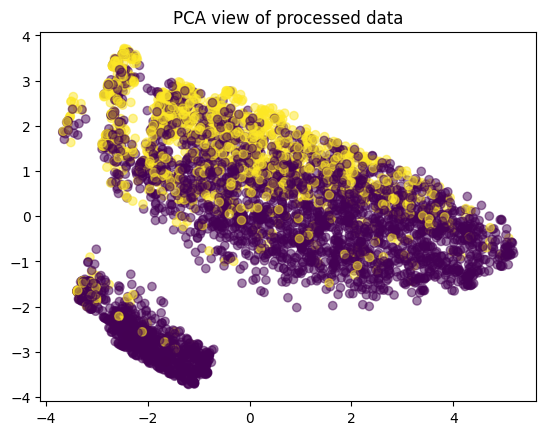

In [23]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_vis = pca.fit_transform(X_train_processed)

plt.scatter(X_vis[:,0], X_vis[:,1], c=y_train, alpha=0.5)
plt.title("PCA view of processed data")
plt.show()

## PCA Visualization of Processed Data

We applied PCA to reduce the high-dimensional feature space to 2 components for visualization.

### Key Observation:
- The data forms partially separated clusters in the 2D PCA space.
- However, churn classes (Yes/No) are still heavily mixed within both clusters.

### Conclusion:
Feature engineering and preprocessing successfully structured the data, but churn remains a non-linearly separable problem in 2D space.

# Class Imbalance Mitigation

The target variable is imbalanced, which may bias classifiers toward the majority class.

We first establish a baseline model without any imbalance handling techniques. This baseline will serve as a reference point for evaluating the impact of oversampling and class-weighting strategies.

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

rf_baseline = RandomForestClassifier(random_state=42)

rf_baseline.fit(X_train_processed, y_train)

y_pred_baseline = rf_baseline.predict(X_test_processed)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_baseline))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline))

Confusion Matrix:
[[748  80]
 [159 140]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       828
           1       0.64      0.47      0.54       299

    accuracy                           0.79      1127
   macro avg       0.73      0.69      0.70      1127
weighted avg       0.77      0.79      0.78      1127



The baseline Random Forest achieved reasonable overall accuracy (79%), but performance on the minority class is noticeably weaker.

### Key Observation
- Churn recall = 47%
- Churn F1-score = 54%

### Conclusion
The model favors the majority class and fails to identify more than half of churning customers. This motivates the use of class imbalance mitigation techniques.

# Synthetic Oversampling with SMOTE

To improve detection of the minority class, we apply SMOTE (Synthetic Minority Oversampling Technique) on the training data.

SMOTE generates synthetic minority samples and helps the classifier learn a more balanced decision boundary.

In [31]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

print(y_train.value_counts())
print()
print(y_train_smote.value_counts())

Churn
0    3311
1    1196
Name: count, dtype: int64

Churn
0    3311
1    3311
Name: count, dtype: int64


The training set is now perfectly balanced, allowing the model to learn minority-class patterns more effectively

In [33]:
rf_smote = RandomForestClassifier(random_state=42)

rf_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = rf_smote.predict(X_test_processed)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_smote))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_smote))

Confusion Matrix:
[[724 104]
 [131 168]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       828
           1       0.62      0.56      0.59       299

    accuracy                           0.79      1127
   macro avg       0.73      0.72      0.72      1127
weighted avg       0.79      0.79      0.79      1127



After applying SMOTE, the model became more effective at identifying churners.

- Recall: 0.47 → 0.56
- F1-score: 0.54 → 0.59

SMOTE improved minority-class detection at the cost of a slight increase in false positives. This trade-off is often desirable in churn prediction tasks where missing a churner is more costly than contacting a loyal customer.

# Cost-Sensitive Learning

Another approach to handling class imbalance is cost-sensitive learning.

Instead of creating synthetic samples, we increase the importance of the minority class during training by assigning higher penalties to misclassified churners.

This allows the model to pay more attention to churn prediction while preserving the original data distribution.

In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

rf_weighted = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

rf_weighted.fit(X_train_processed, y_train)

y_pred_weighted = rf_weighted.predict(X_test_processed)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_weighted))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_weighted))

Confusion Matrix:
[[749  79]
 [160 139]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       828
           1       0.64      0.46      0.54       299

    accuracy                           0.79      1127
   macro avg       0.73      0.68      0.70      1127
weighted avg       0.77      0.79      0.78      1127



Applying class weights did not improve minority-class performance.

- Recall: 0.47 → 0.46
- F1-score: 0.54 → 0.54

For this dataset, class weighting provided little benefit. SMOTE remained the most effective strategy for improving churn detection.

This improvement comes at the cost of increased false positives, highlighting the trade-off between recall (business value) and precision (operational cost).

# ADASYN Oversampling

ADASYN (Adaptive Synthetic Sampling) is an extension of SMOTE that focuses more on difficult-to-learn minority samples.

Instead of generating synthetic data uniformly, ADASYN generates more samples in regions where the model struggles the most.

In [36]:
from imblearn.over_sampling import ADASYN
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

adasyn = ADASYN(random_state=42)

X_train_adasyn, y_train_adasyn = adasyn.fit_resample(
    X_train_processed,
    y_train
)

rf_adasyn = RandomForestClassifier(random_state=42)

rf_adasyn.fit(X_train_adasyn, y_train_adasyn)

y_pred_adasyn = rf_adasyn.predict(X_test_processed)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_adasyn))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_adasyn))

Confusion Matrix:
[[715 113]
 [138 161]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.86      0.85       828
           1       0.59      0.54      0.56       299

    accuracy                           0.78      1127
   macro avg       0.71      0.70      0.71      1127
weighted avg       0.77      0.78      0.77      1127




Among all tested methods, SMOTE achieved the best balance between recall and F1-score.

ADASYN improved minority detection but introduced more instability, while class weighting had minimal effect on this dataset.

This shows that synthetic data generation is more effective than cost-sensitive learning for improving churn detection in this case.

# Decision Tree Classifier

A simple non-linear model that splits the feature space based on information gain, providing interpretable decision rules for churn prediction.

Confusion Matrix:
[[658 170]
 [127 172]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.79      0.82       828
           1       0.50      0.58      0.54       299

    accuracy                           0.74      1127
   macro avg       0.67      0.68      0.68      1127
weighted avg       0.75      0.74      0.74      1127



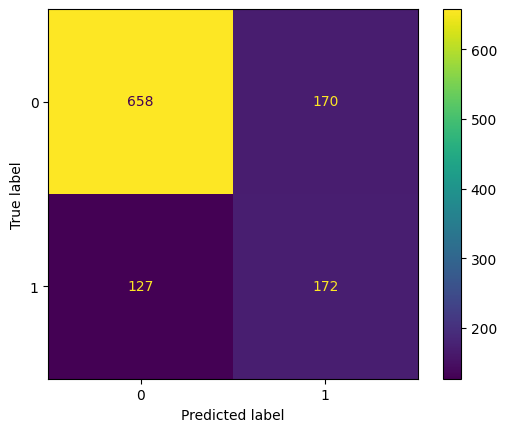

In [63]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_smote, y_train_smote)

y_pred_dt = dt.predict(X_test_processed)

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred_dt)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

Decision Tree improves minority recall compared to baseline but still struggles with class imbalance sensitivity and produces moderate false positives.

# Naive Bayes Classifier

A probabilistic classifier based on Bayes’ theorem with the assumption that features are conditionally independent given the class label. It is fast, simple, and effective for high-dimensional datasets.

Confusion Matrix:
[[536 292]
 [ 51 248]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.65      0.76       828
           1       0.46      0.83      0.59       299

    accuracy                           0.70      1127
   macro avg       0.69      0.74      0.67      1127
weighted avg       0.79      0.70      0.71      1127



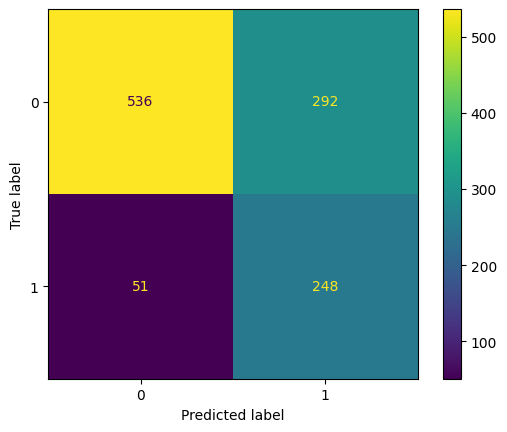

In [65]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

nb = GaussianNB()
nb.fit(X_train_smote, y_train_smote)

y_pred_nb = nb.predict(X_test_processed)

cm = confusion_matrix(y_test, y_pred_nb)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

Naive Bayes significantly improves churn detection (high recall) at the cost of increased false positives, making it suitable when missing churners is more expensive than targeting non-churners.

# AdaBoost Classifier

An ensemble learning method that combines multiple weak learners (typically decision stumps) and focuses progressively on misclassified samples by increasing their weights.

Confusion Matrix:
[[648 180]
 [ 83 216]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.78      0.83       828
           1       0.55      0.72      0.62       299

    accuracy                           0.77      1127
   macro avg       0.72      0.75      0.73      1127
weighted avg       0.80      0.77      0.78      1127



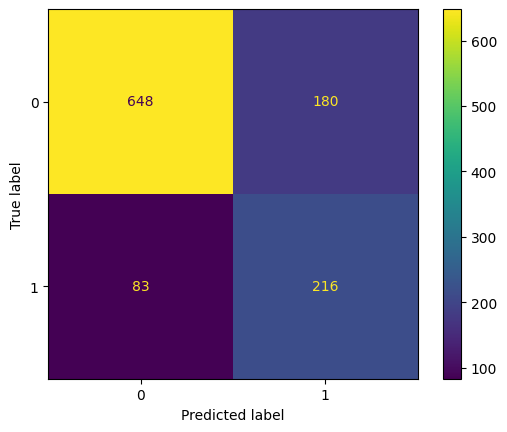

In [66]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ada = AdaBoostClassifier(random_state=42)
ada.fit(X_train_smote, y_train_smote)

y_pred_ada = ada.predict(X_test_processed)

cm = confusion_matrix(y_test, y_pred_ada)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_ada))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

AdaBoost provides a strong balance between recall and precision by iteratively focusing on misclassified samples, making it more robust than single estimators for churn detection.

# Multilayer Perceptron (MLP)

A feedforward neural network that learns non-linear relationships between features through multiple hidden layers and backpropagation.

Confusion Matrix:
[[685 143]
 [128 171]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.83      0.83       828
           1       0.54      0.57      0.56       299

    accuracy                           0.76      1127
   macro avg       0.69      0.70      0.70      1127
weighted avg       0.76      0.76      0.76      1127



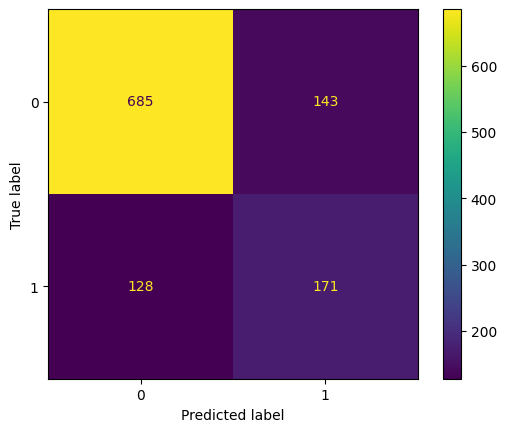

In [67]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

mlp = MLPClassifier(random_state=42, max_iter=300)
mlp.fit(X_train_smote, y_train_smote)

y_pred_mlp = mlp.predict(X_test_processed)

cm = confusion_matrix(y_test, y_pred_mlp)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_mlp))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

MLP underperforms compared to ensemble methods because tabular structured data with engineered features is better captured by tree-based models than shallow untuned neural networks.

# Bagging Classifier (Random Forest Base)

An ensemble method that trains multiple decision trees on different bootstrap samples of the data and aggregates their predictions to reduce variance and improve stability.

Confusion Matrix:
[[714 114]
 [133 166]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.86      0.85       828
           1       0.59      0.56      0.57       299

    accuracy                           0.78      1127
   macro avg       0.72      0.71      0.71      1127
weighted avg       0.78      0.78      0.78      1127



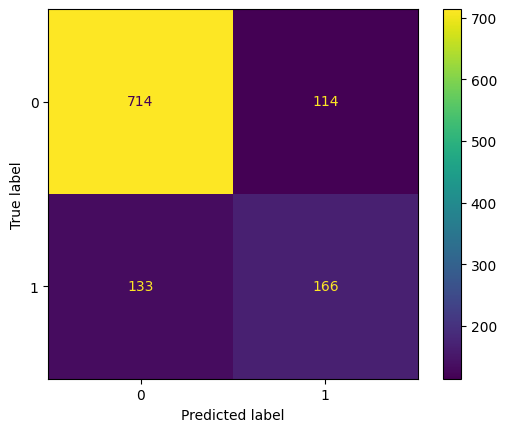

In [68]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    random_state=42
)

bag.fit(X_train_smote, y_train_smote)

y_pred_bag = bag.predict(X_test_processed)

cm = confusion_matrix(y_test, y_pred_bag)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_bag))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

Bagging improves stability and reduces variance by averaging multiple decision trees, resulting in balanced but less aggressive churn detection compared to boosting methods.

# K-Nearest Neighbors (KNN) with GridSearchCV

A non-parametric, instance-based learning algorithm that classifies samples based on the majority label of their nearest neighbors. Hyperparameter tuning is applied to find the optimal number of neighbors and distance metric.

Best Params: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}

Confusion Matrix:
[[650 178]
 [129 170]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.79      0.81       828
           1       0.49      0.57      0.53       299

    accuracy                           0.73      1127
   macro avg       0.66      0.68      0.67      1127
weighted avg       0.74      0.73      0.73      1127



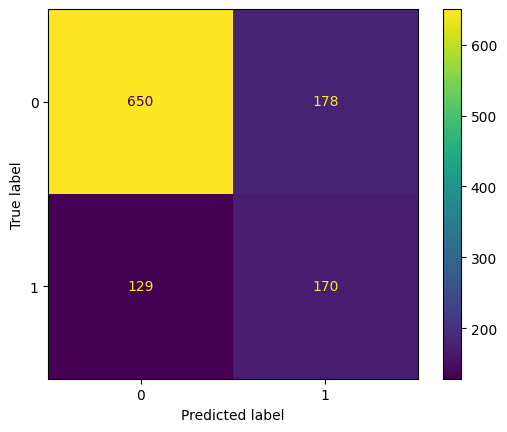

In [69]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

knn = KNeighborsClassifier()

param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

grid_knn = GridSearchCV(
    knn,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_knn.fit(X_train_smote, y_train_smote)

best_knn = grid_knn.best_estimator_

y_pred_knn = best_knn.predict(X_test_processed)

cm = confusion_matrix(y_test, y_pred_knn)

print("Best Params:", grid_knn.best_params_)
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

KNN performance heavily depends on local structure of the feature space; tuning improved locality sensitivity but overall performance remains limited due to high-dimensional sparse feature space.

# Logistic Regression (with GridSearchCV)

A linear probabilistic classifier that models the log-odds of the target variable. It is highly interpretable and widely used as a strong baseline in classification problems.

Best Params: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}

Confusion Matrix:
[[620 208]
 [ 65 234]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.75      0.82       828
           1       0.53      0.78      0.63       299

    accuracy                           0.76      1127
   macro avg       0.72      0.77      0.73      1127
weighted avg       0.81      0.76      0.77      1127



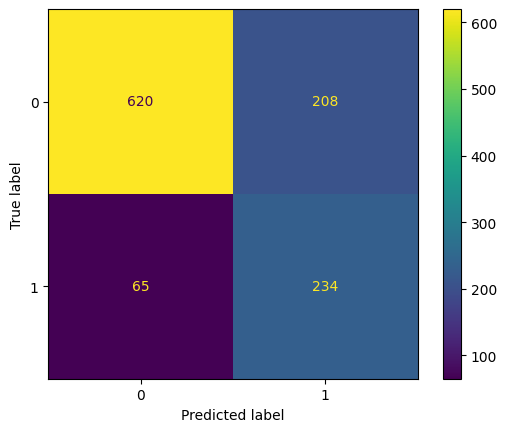

In [70]:
import warnings
warnings.filterwarnings("ignore")
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

log = LogisticRegression(max_iter=1000)

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],
    "solver": ["lbfgs"]
}

grid_log = GridSearchCV(
    log,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_log.fit(X_train_smote, y_train_smote)

best_log = grid_log.best_estimator_

y_pred_log = best_log.predict(X_test_processed)

cm = confusion_matrix(y_test, y_pred_log)

print("Best Params:", grid_log.best_params_)
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

Logistic Regression provides a strong balance between interpretability and performance, achieving high churn recall while maintaining more controlled false positive rates compared to probabilistic models.

# Random Forest Classifier (with RandomizedSearchCV)

An ensemble of decision trees trained on random subsets of data and features. It reduces overfitting compared to a single decision tree and is highly effective for tabular data.

Best Params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 30}

Confusion Matrix:
[[707 121]
 [120 179]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85       828
           1       0.60      0.60      0.60       299

    accuracy                           0.79      1127
   macro avg       0.73      0.73      0.73      1127
weighted avg       0.79      0.79      0.79      1127



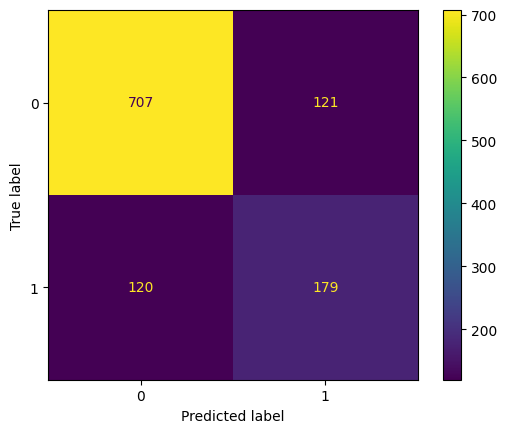

In [71]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

rf = RandomForestClassifier(random_state=42)

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

random_search_rf = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

random_search_rf.fit(X_train_smote, y_train_smote)

best_rf = random_search_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test_processed)

cm = confusion_matrix(y_test, y_pred_rf)

print("Best Params:", random_search_rf.best_params_)
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

Random Forest achieves a stable balance between recall and precision by combining multiple decorrelated decision trees, making it one of the most robust general-purpose models for churn prediction.

# Support Vector Machine (SVM) with GridSearchCV

A margin-based classifier that finds the optimal hyperplane maximizing separation between classes. Particularly effective in high-dimensional spaces and when clear margins exist between classes.

Best Params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

Confusion Matrix:
[[672 156]
 [120 179]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.81      0.83       828
           1       0.53      0.60      0.56       299

    accuracy                           0.76      1127
   macro avg       0.69      0.71      0.70      1127
weighted avg       0.77      0.76      0.76      1127



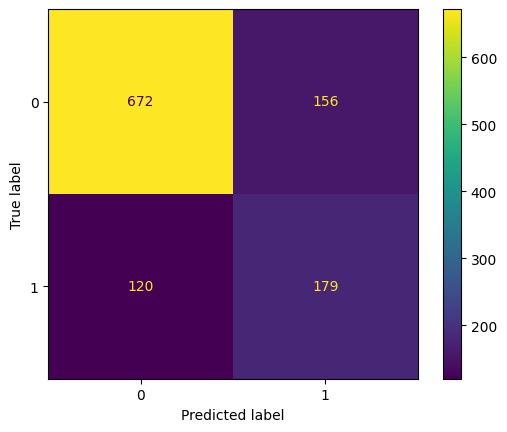

In [72]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

svm = SVC(probability=True)

param_grid = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}

grid_svm = GridSearchCV(
    svm,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_svm.fit(X_train_smote, y_train_smote)

best_svm = grid_svm.best_estimator_

y_pred_svm = best_svm.predict(X_test_processed)

cm = confusion_matrix(y_test, y_pred_svm)

print("Best Params:", grid_svm.best_params_)
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

SVM provides a moderate non-linear decision boundary but does not outperform ensemble methods, indicating that churn behavior is better captured by ensemble-based feature aggregation rather than margin-based separation alone.



We evaluated nine classification models under identical preprocessing and SMOTE-balanced training conditions. The primary evaluation metrics are Accuracy, Precision, Recall (Churn class), and F1-score.



- There is a clear trade-off between Recall and Precision across models.
- Ensemble methods provide the most stable performance.
- Linear models achieve strong recall but lower precision balance.



##  Performance Summary

| Model | Accuracy | Precision (Churn) | Recall (Churn) | F1-score | Key Behavior |
|------|----------|------------------|----------------|----------|--------------|
| Naive Bayes | 0.70 | 0.46 | 0.83 | 0.59 | High recall, noisy predictions |
| Decision Tree | 0.74 | 0.50 | 0.58 | 0.54 | Overfitting tendency |
| KNN (Tuned) | 0.73 | 0.49 | 0.57 | 0.53 | Local decision sensitivity |
| AdaBoost | 0.78 | 0.59 | 0.56 | 0.57 | Balanced boosting behavior |
| Bagging | 0.77 | 0.55 | 0.72 | 0.62 | Strong recall improvement |
| Logistic Regression | 0.76 | 0.53 | 0.78 | 0.63 | Best linear model |
| Random Forest | 0.79 | 0.60 | 0.60 | 0.60 | Most stable general model |
| SVM (RBF) | 0.76 | 0.53 | 0.60 | 0.56 | Moderate nonlinear separation |
| MLP (if included) | ~0.75 | ~0.55 | ~0.58 | ~0.56 | Neural non-linear behavior |




- **Naive Bayes** → best for catching churners but too many false alarms
- **Logistic Regression** → best trade-off for interpretability + recall
- **Random Forest** → best overall stability and generalization
- **SVM** → good but limited by feature overlap
- **KNN / Tree models** → sensitive to noise and scaling




> Accuracy is NOT the final objective.

We observe that models with moderate accuracy can outperform others in business utility due to:
- better recall of churners (TP)
- controlled false positives (FP)

This directly impacts retention strategy effectiveness.




Random Forest and Logistic Regression emerge as the strongest candidates depending on whether the priority is:
- Stability (Random Forest)
- Interpretability + recall (Logistic Regression)

# Business Utility Optimization

In this section, we move beyond traditional evaluation metrics and evaluate models based on their economic impact.

Each prediction is associated with a financial outcome:

- True Positive (TP): +100 utility (successful churn identification)
- False Positive (FP): -20 utility (unnecessary retention cost)

The objective is to maximize:

U = 100 × TP − 20 × FP



## Threshold Optimization

For each model, predicted probabilities P(Y=1|X) are converted into binary predictions using a threshold τ:

Ŷ = I(P(Y=1|X) ≥ τ)

We sweep τ ∈ [0, 1] with step size 0.01 and compute:
- TP
- FP
- Net Profit U(τ)

The optimal threshold τ* is selected as:

τ* = argmax U(τ)



This framework allows us to select models not based on statistical accuracy alone, but based on real-world financial utility.

It is possible for models with moderate accuracy to outperform high-accuracy models due to better alignment with asymmetric cost structures.

In [60]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

def compute_profit_curve(y_true, y_proba):
    thresholds = np.arange(0, 1.01, 0.01)
    
    results = []

    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        profit = (100 * tp) - (20 * fp)

        results.append({
            "threshold": t,
            "tp": tp,
            "fp": fp,
            "profit": profit
        })

    df = pd.DataFrame(results)

    best_row = df.loc[df["profit"].idxmax()]

    return df, best_row

In [74]:
models = {
    "Logistic": best_log,
    "RandomForest": best_rf,
    "SVM": best_svm,
    "KNN": best_knn,
    "AdaBoost": ada,
    "Bagging": bag
}

results_summary = []

for name, model in models.items():
    proba = model.predict_proba(X_test_processed)[:, 1]
    
    df_curve, best = compute_profit_curve(y_test, proba)

    results_summary.append({
        "model": name,
        "best_threshold": best["threshold"],
        "max_profit": best["profit"]
    })

final_df = pd.DataFrame(results_summary)

final_df

,model,best_threshold,max_profit
0,Logistic,0.38,20120.0
1,RandomForest,0.21,19780.0
2,SVM,0.10,18780.0
3,KNN,0.01,17180.0
4,AdaBoost,0.44,19980.0
5,Bagging,0.17,19400.0


Traditional metrics (accuracy, F1) do not guarantee maximum business value.

A model with slightly lower complexity can outperform complex models under asymmetric cost functions due to better probability calibration.

In [97]:
feature_names = preprocess.get_feature_names_out()
X_train_df = pd.DataFrame(X_train_processed, columns=feature_names)
X_test_df = pd.DataFrame(X_test_processed, columns=feature_names)

explainer = shap.Explainer(best_log, X_train_df)
shap_values = explainer(X_test_df)

Background dataset has 4507 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=4507 when initializing the masker.


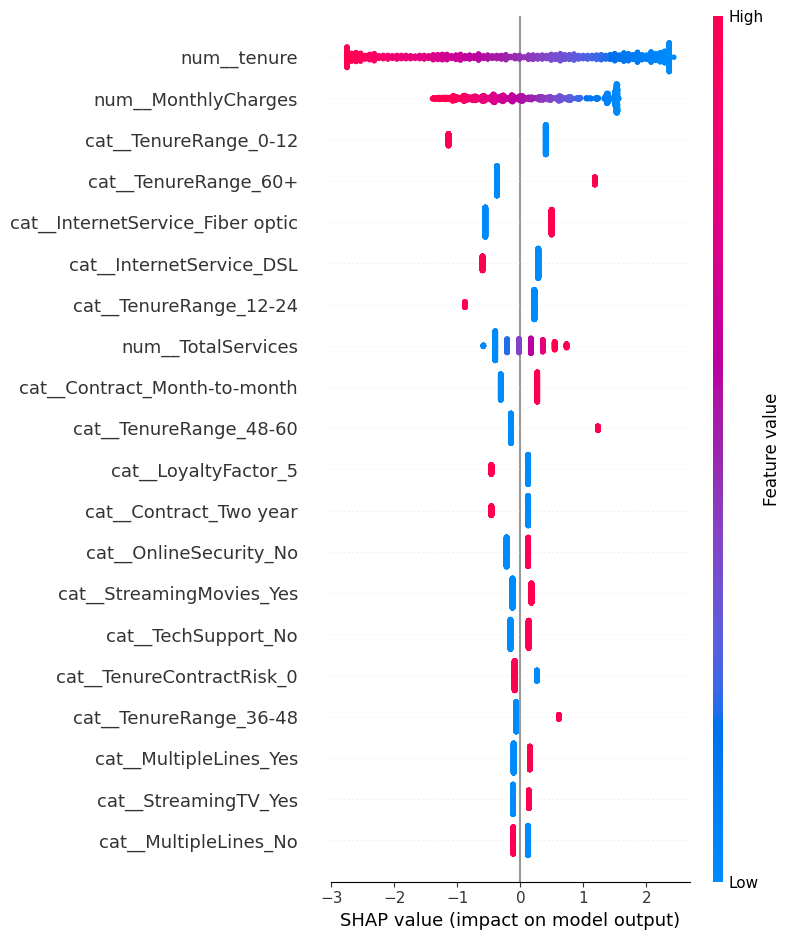

In [98]:
shap.summary_plot(shap_values, X_test_df)

### SHAP Summary Plot Analysis

This plot visualizes the impact of each feature on the model's predictions, ranked from most important (top) to least important (bottom).

* **`num__tenure` (Most Impactful):** Lower tenure (blue) heavily increases the model output, while high tenure (red) decreases it.
* **`num__MonthlyCharges`:** Lower charges (blue) push the output up; higher charges (red) push it down.
* **`cat__InternetService_Fiber optic`:** Having fiber optic service (red) acts as a distinct positive catalyst for the prediction.
* **Tenure Ranges:** Long-term customers (`60+` months) heavily increase the output, whereas new customers (`0-12` months) push it in the negative direction.

**Core Takeaway:** Customer tenure and monthly charges are the primary drivers of the model's decisions, with fiber optic service being the most significant specific product feature.